# Week 4 Day 1 : ML Foundation - Problem Framing, Hold-Out and Baseline
### Goal: 
Set up a train/test split

Make baselines

Do initial error analysis

### Dataset

We are using the Adult Census Income Dataset.

The goal is to predict whether someone's yearly income is:

* 0 = <=50K
* 1 = >50K

## Imports and Loading

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# checking the base rate
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


fnlwgt stands for final weight. Rows with the same demographic characteristics (age, sex, education, etc.) share the same fnlwgt

In [3]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='str')

gonna rename class to income

In [4]:
df.rename(columns={"class": "income"}, inplace=True)
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

In [5]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
#checking class base rate
base_rate = df["income"].value_counts(normalize=True) * 100
print((base_rate))

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


## Task 1: Problem Definition & Success Metric

### Problem
The problem is that we want customers whose annual income is greater that 50k. If we are looking at everyone in the data given, its going to be an unnecessary waste of time and budget. 


### Target:
* **Column**: income/class
* **Targetted**: High income customers = income that is >= 50k

### Business Objective:
The goal is to find high-income people as our targets so we can sell them the premium goods. This will ultimately reduce marketing costs and focus more on people who are likely to spend.

### Base Rate:
The base rate of the positive class (1 OR  > 50k) is 23.92% ~= 24% While for the negative class its  76.07%. So that means theres a smaller number of customers with high income. We have got to target them.


### Primary Evaluation Metric:
Out of the 3 mentioned, it would be best to go with **Precision**, specifically precision@k. Precision@K is a variation of standard Precision that limits the evaluation to a specific number of top results (K)

**Reason**: Since we are targetting certain customers (high-end ones), it would be better to go with precision because accidentally contacting low-income ones would waste resources such as marketing resources. Its better to contact fewer targeted people with higher confidence than to contact many people who are unlikely to be interested.

### Trade-off b/w Precision and Recall
I chose precision since our goal is to correctly identify the people who earn > 50k without incorrectly labeling too many lower income people as high income. This helps reduce marketing efforts and costs that go to waste. 

The trade-off is that the model may miss some actual high-income individuals (lower recall), but avoiding false positives is more important for this business objective. That is why we need to be precise.

## For Non-Technical Stakeholders
Our goal is to predict what incoming customers earn more that $50,000 a year. This way only those customers who can afford it will be contacted for the premium offers. 

## Task 2: Data Load and EDA
Since we already loaded in the dataset using:
```python
sklearn.datasets.fetch_openml('adult')
```
we will jump straight into EDA

#### Converting target "income" to binary (0/1)

In [7]:
df["income"] = df["income"].map({"<=50K" : 0, ">50K" : 1})

In [8]:
df["income"].value_counts()

income
0    37155
1    11687
Name: count, dtype: int64

donee
#### Clean Missing Values (Converting ? to NAN)


In [9]:
(df == '?').sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [10]:
print((df == '?').any().any())

False


In [11]:
print(df.eq('?').sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [11]:
df.isin(['?']).any().any()

np.False_

In [12]:
df.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [13]:
df.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [14]:
df = df.replace("?", np.nan)

My bad. I thought it would remove it so i kept running the same line of code. Gotta find out if it really has been replaced.

In [15]:
df.isin(['?']).any().any()

np.False_

In [16]:
df["native-country"].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
48837    False
48838    False
48839    False
48840    False
48841    False
Name: native-country, Length: 48842, dtype: bool

In [17]:
print(df.isnull().sum())

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


**Note**: So turns out there were no "?"s in my dataset to begin with, thats why i saw no changes, i couldve entirely skipped this part

### EDA

In [12]:
# shape
df.shape

(48842, 15)

In [13]:
#column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  income          48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [14]:
#numeric summaries
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [27]:
categorical_cols = df.select_dtypes(include="category").columns
print(df[categorical_cols].value_counts().head(20))

#this does NOT look good

workclass  education     marital-status      occupation         relationship  race   sex     native-country  income
Private    HS-grad       Married-civ-spouse  Craft-repair       Husband       White  Male    United-States   0         795
           Bachelors     Married-civ-spouse  Exec-managerial    Husband       White  Male    United-States   1         535
           HS-grad       Married-civ-spouse  Craft-repair       Husband       White  Male    United-States   1         395
                                             Machine-op-inspct  Husband       White  Male    United-States   0         390
                                             Transport-moving   Husband       White  Male    United-States   0         339
           Bachelors     Married-civ-spouse  Prof-specialty     Husband       White  Male    United-States   1         338
                                             Sales              Husband       White  Male    United-States   1         306
           Some-college

In [23]:
cat_summary = pd.DataFrame({
    "Column": categorical_cols,
    "Unique Values": [df[col].nunique() for col in categorical_cols],
    "Missing Values": [df[col].isna().sum() for col in categorical_cols]
})

cat_summary

,Column,Unique Values,Missing Values
0,workclass,8,2799
1,education,16,0
2,marital-status,7,0
3,occupation,14,2809
4,relationship,6,0
5,race,5,0
6,sex,2,0
7,native-country,41,857
8,income,2,0


### Visualizations (histograms + bar plots)

#### Histograms For Numeric Columns

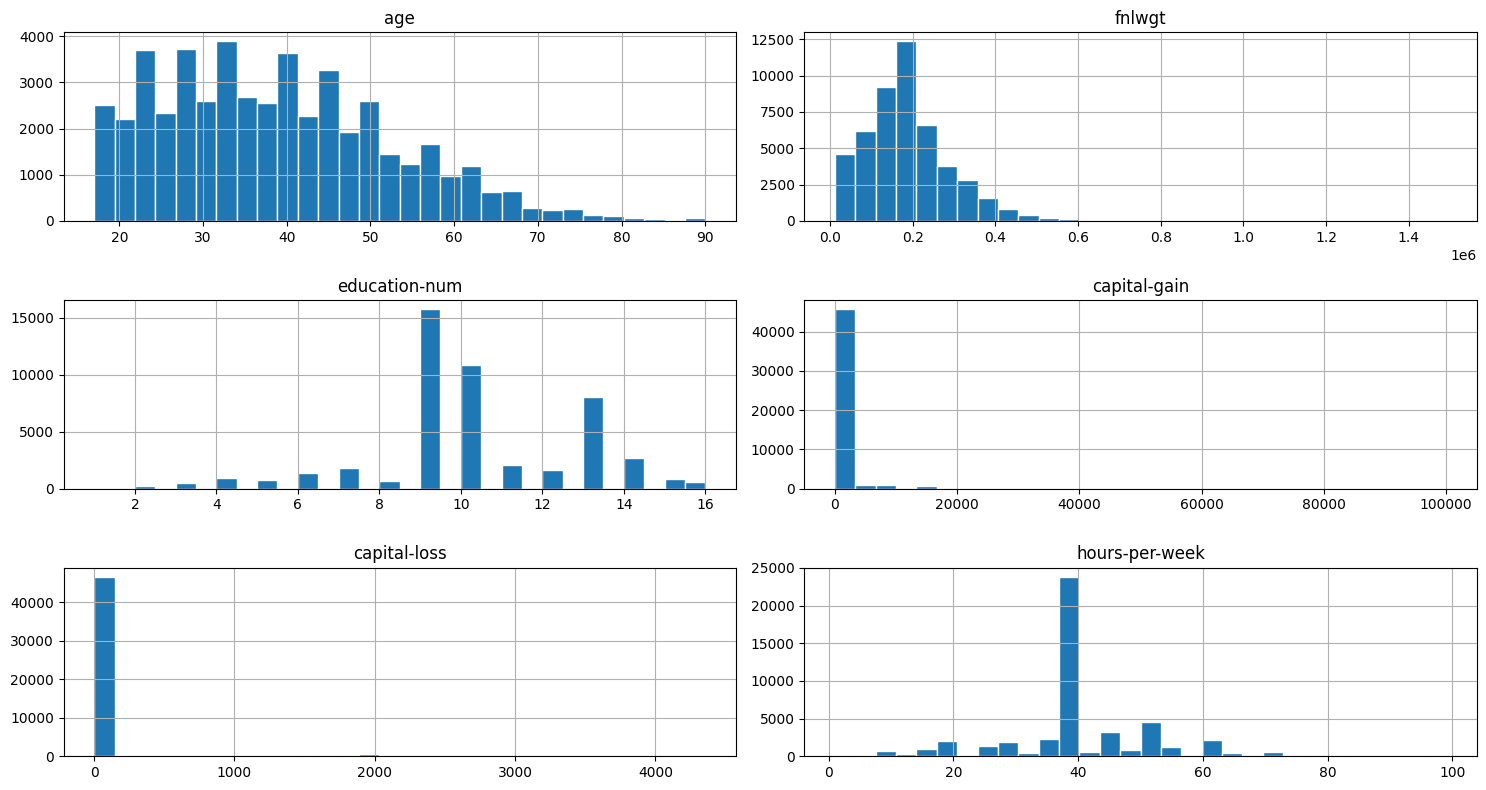

In [60]:
numeric_cols = df.select_dtypes(include=["int64"]).columns

df[numeric_cols].hist(figsize=(15, 8), bins = 30, edgecolor="white")
plt.tight_layout()
plt.show()

#### Barplots for Categorical Columns

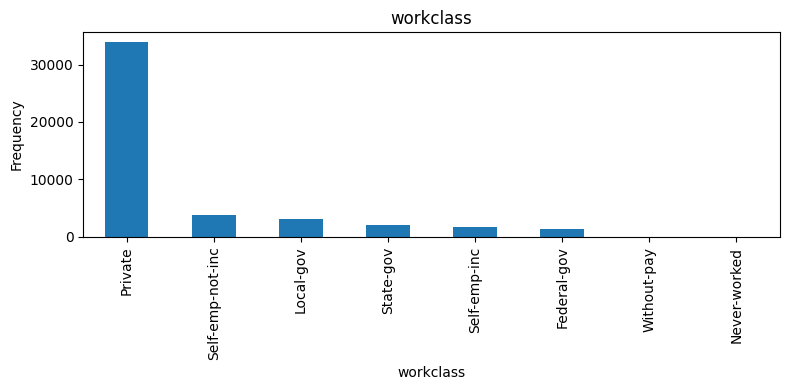

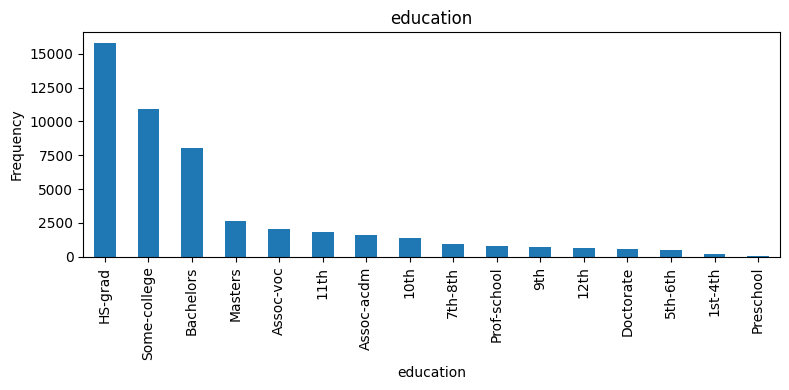

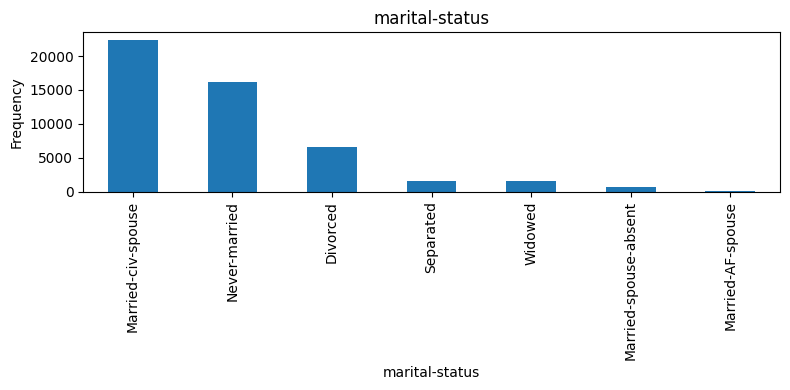

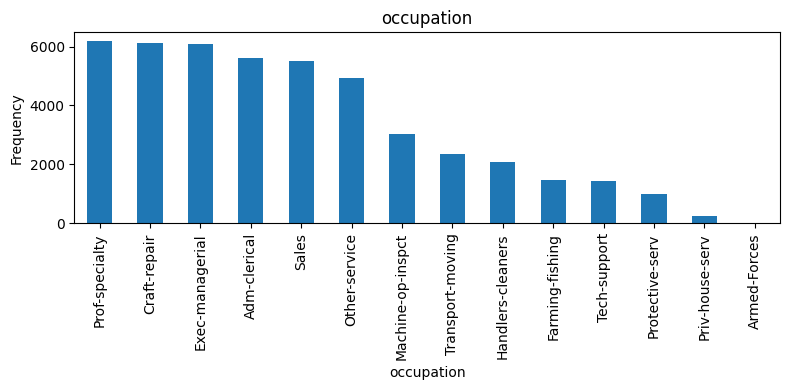

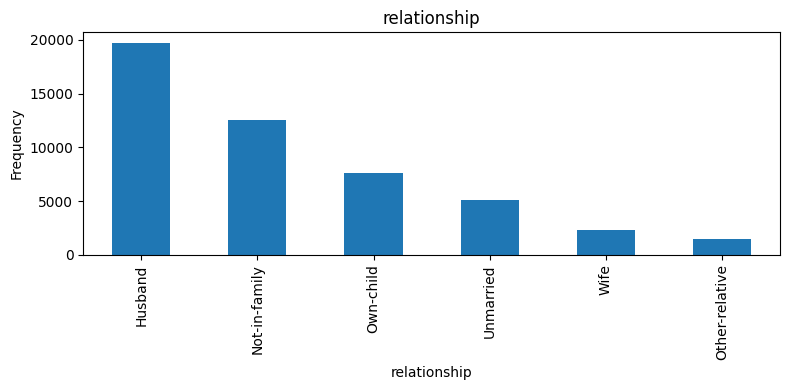

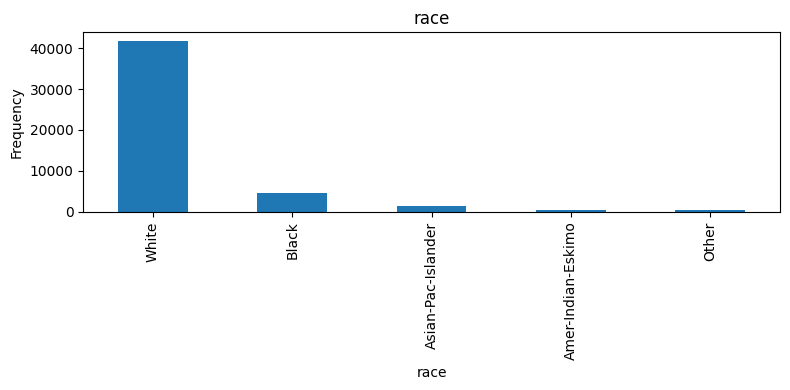

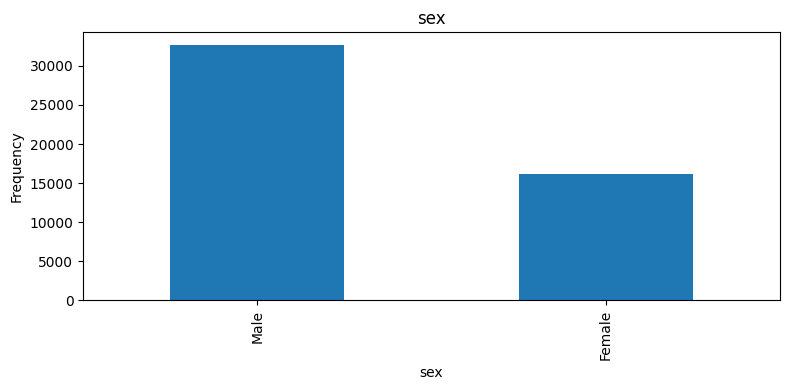

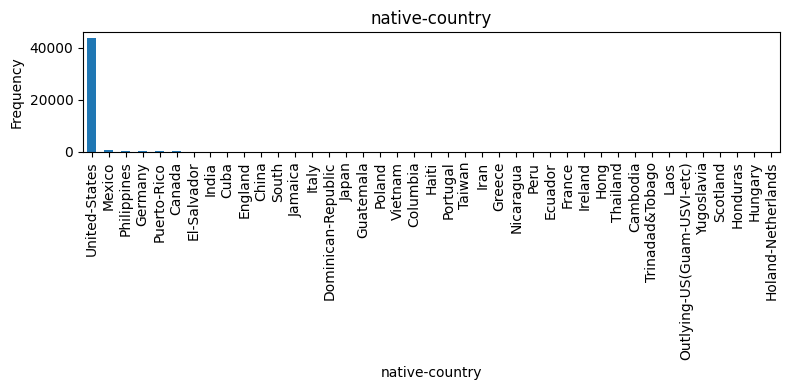

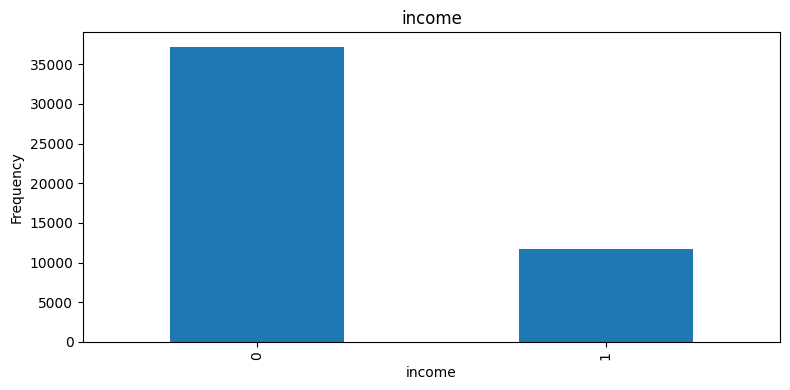

In [51]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.xticks(rotation=90)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

#### Summary Table

In [31]:
summary = (
    df["income"]
      .value_counts()
      .rename_axis("Income")
      .reset_index(name="Count")
)

summary

,Income,Count
0,0,37155
1,1,11687


### Atleast 3 Notable feature distributions (did 4)

In [63]:
notable = pd.DataFrame({
    "Mean Age": df.groupby("income")["age"].mean(),
    "Mean Education Years": df.groupby("income")["education-num"].mean(),
    "Mean Hours/Week": df.groupby("income")["hours-per-week"].mean(),
    "% with Capital Gain > 0": df.groupby("income")["capital-gain"].apply(lambda s: (s > 0).mean() * 100)
})

notable = notable.round(2)
notable

,Mean Age,Mean Education Years,Mean Hours/Week,% with Capital Gain > 0
income,,,,
0,36.87,9.6,38.84,4.16
1,44.28,11.6,45.45,21.31


In [64]:
summary.to_csv("class_summary.csv")
notable.to_csv("notable_feature_distributions.csv")

### Observations

* Most people in the dataset earn $\$50K$ or less, so the dataset is imbalanced.
* High earners are older on average. They are around 44 years old, while lower earners are around 37, so income generally increases with career experience.
* High earners also have more education. On average, they have about 2 extra years of education compared to lower earners.
* People earning more than $50K work slightly longer hours, around 45.5 hours per week compared to 38.8 hours, but this difference is not as big as age or education.
* Capital gain is the strongest indicator of higher income. Around 21% of high earners have capital gains, compared to only about 4% of lower earners.
* Overall, the features are most useful in this order: capital gain, age, education, then hours worked per week.
* Most people in the dataset work in the Private sector.
* Most people are from the United States, with smaller numbers from countries like Mexico, the Philippines, and Germany.
* The age distribution is spread across a wide range, so the dataset includes both younger and older adults.
* Working 40 hours per week is the most common.
* Most people have a High School education.

## Task 3: Creating Splits

In [67]:
X = df.drop("income", axis=1)
y = df["income"]

In [68]:
# splitting 80-20 (cant use it rn)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y) 

In [69]:
#optional dev split
X_train, X_dev, y_train, y_dev = train_test_split( X_train, y_train, test_size=0.10, stratify=y_train, random_state=42)

In [72]:
print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Test:", X_test.shape)

Training: (35165, 14)
Development: (3908, 14)
Test: (9769, 14)


In [75]:
print(y_train.value_counts(normalize=True))
print(y_dev.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

income
0    0.760728
1    0.239272
Name: proportion, dtype: float64
income
0    0.760747
1    0.239253
Name: proportion, dtype: float64
income
0    0.760672
1    0.239328
Name: proportion, dtype: float64


Okay so the propostions are similar in all 3, thats good, lets move on

#### Need for a hold-out test and what goes wrong if you use it during hyperparameter tuning
The hold-out test set is kept separate so we can measure how well the model performs on unseen data.

If we leak the test set into tuning, we pretty much lose our only unbiased check and risk deploying a model that looks great in development but underperforms in production

## Task 4: Implement Simple Baselines

### Baseline 1: Majority-Class Predictor
this'll predict the most common class

In [83]:
majority_class = y.mode()[0]
print(f"The majority class is: {majority_class}")


The majority class is: 0


In [84]:
y_pred_majority = np.full(len(y_test), majority_class)

In [85]:
y_pred_majority

array([0, 0, 0, ..., 0, 0, 0], shape=(9769,))

### Baseline 2: Rule-Based Classifier (Single-feature)

In [110]:

y_pred_rule = (X_test["education-num"] >= 13).astype(int)
y_pred_rule

40342    0
47680    0
524      0
8508     0
31692    0
        ..
20384    0
28000    0
22163    1
24733    0
47829    0
Name: education-num, Length: 9769, dtype: int64

#### Gonna try captial-gain >0 too and hours per week

In [111]:
y_pred_rule_cap_gain = (X_test["capital-gain"] > 0).astype(int)

In [112]:
y_pred_rule_hours_per_week = (X_test["hours-per-week"] >= 45).astype(int)

### Evalutation

In [108]:
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_pred),
        "PR AUC": average_precision_score(y_true, y_pred)
    }

In [109]:
majority_results = evaluate_model(y_test, y_pred_majority)
education_rule_results = evaluate_model(y_test, y_pred_rule)
capital_gain_rule_results = evaluate_model(y_test, y_pred_rule_cap_gain)
hpw_rule_results = evaluate_model(y_test, y_pred_rule_hours_per_week)

metrics = pd.DataFrame(
    [majority_results, rule_results, capital_gain_rule_results, hpw_rule_results],
    index=["Majority Class", "Education Rule", "Capital Gain Rule", "HPW Rule"]
)

metrics.round(3)

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Majority Class,0.761,0.000,0.000,0.000,0.500,0.239
Education Rule,0.753,0.484,0.497,0.491,0.665,0.361
Capital Gain Rule,0.782,0.625,0.225,0.331,0.591,0.326
HPW Rule,0.710,0.406,0.453,0.428,0.622,0.315


### Justifying Capital Gain Rule as the Rule-Based Classifier
I chose captial gain rule since any investment income at all is a strong signal of financial means, So it works as a simple, interpretable rule-based classifier

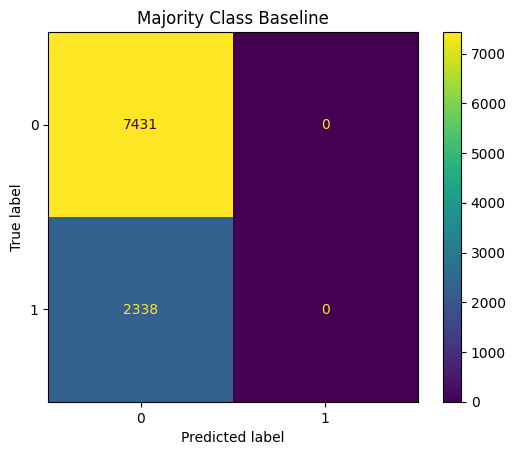

In [99]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_majority
)

plt.title("Majority Class Baseline")
plt.show()

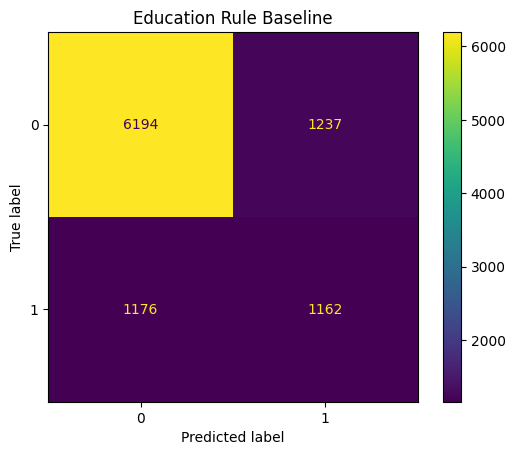

In [100]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rule
)

plt.title("Education Rule Baseline")
plt.show()

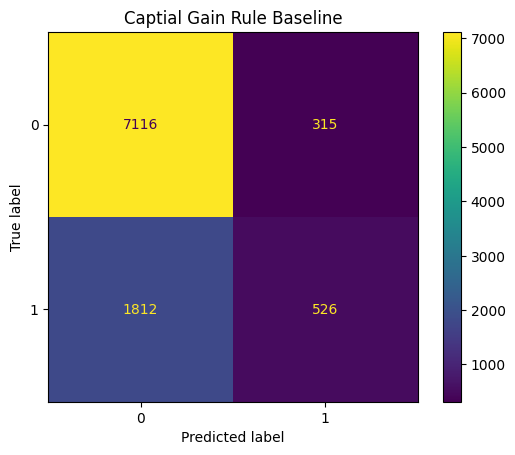

In [101]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rule_cap_gain
)

plt.title("Captial Gain Rule Baseline")
plt.show()

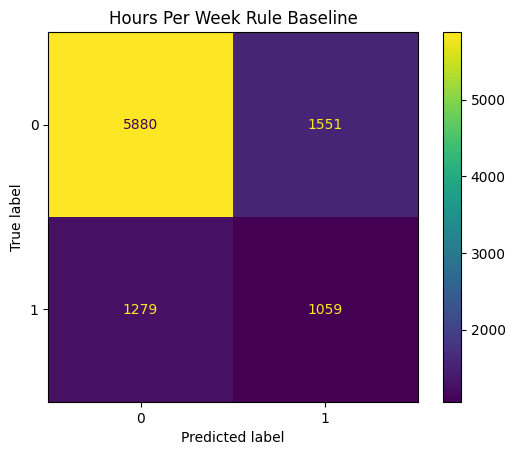

In [113]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rule_hours_per_week
)

plt.title("Hours Per Week Rule Baseline")
plt.show()

### Interpretation
The majority-class predictor gets high accuracy (~76%, matching the base rate) but zero precision so its pretty much useless.

The Capital Gain Rule is the best baseline because it has the highest Precision (0.625) and Accuracy (0.782). Even though the Education Rule has a better F1 score and Recall, Precision is more important for this because we want to avoid wasting marketing efforts on the wrong people. 

A real machine learning model should improve Precision beyond 0.625 while also increasing Recall, so it can identify more high-income individuals without creating too many false positives.

## Task 5: Initial Error Analysis & Next Steps

Gonna do it with captial gain

In [129]:
test_analysis = X_test.copy()
test_analysis["y_true"] = y_test.values
test_analysis["y_pred"] = y_pred_rule_cap_gain

false_positives = test_analysis[(test_analysis.y_true==0) & (test_analysis.y_pred==1)]
false_negatives = test_analysis[(test_analysis.y_true==1) & (test_analysis.y_pred==0)]

print(f"Total false positives: {len(false_positives)}")
print(f"Total false negatives: {len(false_negatives)}")

Total false positives: 315
Total false negatives: 1812


In [133]:
false_positives.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,315.0,NaN,NaN,NaN,42.133333,15.363784,17.0,30.5,39.0,52.5,90.0
workclass,290,6,Private,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,315.0,NaN,NaN,NaN,191446.904762,117516.27053,19302.0,108058.0,177368.0,240967.0,889965.0
education,315,13,HS-grad,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,315.0,NaN,NaN,NaN,9.873016,2.47852,3.0,9.0,9.0,12.0,15.0
marital-status,315,7,Married-civ-spouse,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,290,12,Adm-clerical,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,315,6,Husband,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,315,5,White,276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,315,2,Male,209,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
false_negatives.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1812.0,NaN,NaN,NaN,43.575055,10.318902,22.0,36.0,43.0,50.25,81.0
workclass,1774,6,Private,1164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,1812.0,NaN,NaN,NaN,191195.949779,102293.787823,19914.0,121538.0,179837.5,238168.5,953588.0
education,1812,15,Bachelors,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,1812.0,NaN,NaN,NaN,11.490066,2.371935,2.0,10.0,12.0,13.0,16.0
marital-status,1812,7,Married-civ-spouse,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,1774,13,Prof-specialty,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,1812,6,Husband,1397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,1812,5,White,1635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1812,2,Male,1545,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
fp_sample = false_positives.sample(min(10, len(false_positives)), random_state= 42)
fp_sample[["age","education","education-num","occupation","hours-per-week","capital-gain","marital-status"]]

,age,education,education-num,occupation,hours-per-week,capital-gain,marital-status
37136,22,Some-college,10,Craft-repair,40,2407,Married-civ-spouse
48796,66,10th,6,Craft-repair,40,3471,Married-civ-spouse
45354,32,Some-college,10,Sales,50,4386,Married-civ-spouse
17677,54,HS-grad,9,Transport-moving,40,5013,Married-civ-spouse
23656,39,HS-grad,9,Protective-serv,48,4650,Never-married
31952,39,HS-grad,9,Machine-op-inspct,40,2829,Married-civ-spouse
27437,25,Bachelors,13,Prof-specialty,30,3674,Never-married
37691,74,10th,6,NaN,30,1797,Married-civ-spouse
14884,30,HS-grad,9,Machine-op-inspct,40,3942,Married-civ-spouse
25396,38,Bachelors,13,Exec-managerial,40,3325,Divorced


In [134]:
fn_sample = false_negatives.sample(min(10, len(false_negatives)), random_state=42)
fn_sample[["age","education","education-num","occupation","hours-per-week","capital-gain","marital-status"]]

,age,education,education-num,occupation,hours-per-week,capital-gain,marital-status
10804,38,Bachelors,13,Tech-support,55,0,Married-civ-spouse
13191,33,Bachelors,13,Exec-managerial,60,0,Married-civ-spouse
11819,51,Bachelors,13,Exec-managerial,60,0,Married-spouse-absent
30835,59,Bachelors,13,Sales,55,0,Divorced
25178,29,Some-college,10,Other-service,41,0,Never-married
35575,42,HS-grad,9,Craft-repair,40,0,Married-civ-spouse
8035,31,Masters,14,Adm-clerical,60,0,Never-married
2626,53,Some-college,10,Exec-managerial,50,0,Married-civ-spouse
5796,61,Bachelors,13,Sales,45,0,Married-civ-spouse
1655,30,Some-college,10,Exec-managerial,45,0,Married-civ-spouse


In [137]:
print("False positive patterns (predicted >50K but actually <=50K):")
print(false_positives[["age","hours-per-week","education-num"]].mean())
print()
print("False negative patterns (predicted <=50K but actually >50K):")
print(false_negatives[["age","hours-per-week","education-num"]].mean())


False positive patterns (predicted >50K but actually <=50K):
age               42.133333
hours-per-week    40.609524
education-num      9.873016
dtype: float64

False negative patterns (predicted <=50K but actually >50K):
age               43.575055
hours-per-week    45.421634
education-num     11.490066
dtype: float64


### Patterns
* False negatives are slightly older (43.6 vs 42.1), have more years of education (11.5 vs 9.9), and work more hours per week (45.4 vs 40.6) than false positives.
* This suggests the model is missing many people who earn >50K even though they have characteristics that are often linked to higher income.
* Since the Capital Gain Rule only looks at capital gain, it ignores other useful features like education and hours worked, which leads to many false negatives.
* False positives tend to have lower education and work fewer hours, showing that capital gain alone isn't enough to accurately predict whether someone earns more than $50K.

### Data/Feature Issues
1. **Missing categories** in workclass, occupation, native_country (~2-6% each)
2. **Categorical encoding**: we might need one-hot encoding for workclass, education,
   marital_status, occupation, relationship, race, sex, native_country before feeding a actual model
3. **Skewed numerics**: capital_gain and capital_loss are extremely skewed
4. **Redundant features**: education (categorical) and education_num (numerical) have the same info so we might wanna keep just one
5. **fnlwgt** can be dropped since it does nothing for us
6. **Age is Nonlinear:** earning power vs. age is not linear, will have to look into that too
7. **? Mystery** Tried to find it but didnt get it, not sure if its an issue tho

### Primary Metric to Optimize
For the rest of the week, I'll use **Precision** as the main metric to optimize because the goal is to  identify high-income individuals correctly, while keeping the false positives low. The Capital Gain Rule achieved the highest Precision (0.625) out of all the baselines, making it the best starting point for our objective 

I'll aim to improve precision even further while also increasing Recall so that more high-income individuals are identified correctly.

Okay that's it for the day